In [6]:
import random
import h5py
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.preprocessing import StandardScaler
import math
import random
CLASSIFICATION = 'BINARY'
class_type = CLASSIFICATION
PROJECTION = 'XYZ'
ISOTOPE = 'Mg22'
sample_size = 512

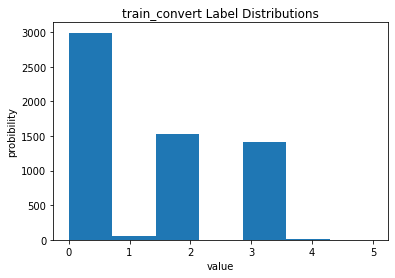

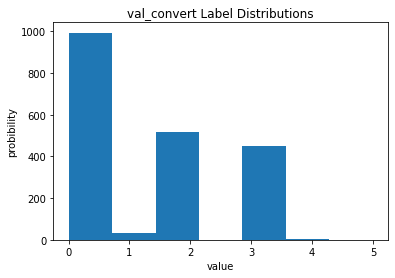

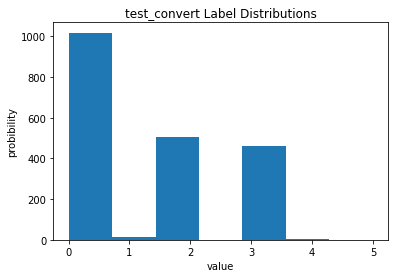

In [7]:
PLOT = 'Label'

DATA_SET_NAME = ['train_convert','val_convert','test_convert']

for i in DATA_SET_NAME:
    data = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_' + i + PROJECTION + '.npy')
    plt.hist(data, bins = 7)
    plt.ylabel('probibility')
    plt.xlabel('value')
    plt.title(i + ' Label' + ' Distributions')
    plt.show()
# plt.savefig('data/'+ '.png', bbox_inches = 'tight') # uncomment to save


In [8]:
train_labels = [0,0,0,0,0,0,0]
train_extras = []
val_labels = [0,0,0,0,0,0,0]
val_extras = []
test_labels = [0,0,0,0,0,0,0]
test_extras = []

train_data = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_train_convert' + PROJECTION + '.npy')
for j in range(len(train_data)):
    if train_data[j] == 0:
        train_labels[0] += 1
    elif train_data[j] == 1:
        train_labels[1] += 1
    elif train_data[j] == 2:
        train_labels[2] += 1
    elif train_data[j] == 3:
        train_labels[3] += 1
    elif train_data[j] == 4:
        train_labels[4] += 1
    elif train_data[j] == 5:
        train_labels[5] += 1
    else:
        train_extras.append(train_data[j])
        train_labels[6] += 1
        
val_data = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_val_convert' + PROJECTION + '.npy')
for j in range(len(val_data)):
    if val_data[j] == 0:
        val_labels[0] += 1
    elif val_data[j] == 1:
        val_labels[1] += 1
    elif val_data[j] == 2:
        val_labels[2] += 1
    elif val_data[j] == 3:
        val_labels[3] += 1
    elif val_data[j] == 4:
        val_labels[4] += 1
    elif val_data[j] == 5:
        val_labels[5] += 1
    else:
        val_extras.append(val_data[j])
        val_labels[6] += 1
        
test_data = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + '_track_labels_test_convert' + PROJECTION + '.npy')
for j in range(len(data)):
    if test_data[j] == 0:
        test_labels[0] += 1
    elif test_data[j] == 1:
        test_labels[1] += 1
    elif test_data[j] == 2:
        test_labels[2] += 1
    elif test_data[j] == 3:
        test_labels[3] += 1
    elif test_data[j] == 4:
        test_labels[4] += 1
    elif test_data[j] == 5:
        test_labels[5] += 1
    else:
        test_extras.append(test_data[j])
        test_labels[6] += 1
        
print(train_labels, val_labels, test_labels)
print(train_extras, val_extras, test_extras)

[2991, 59, 1532, 1406, 9, 3, 0] [993, 33, 519, 452, 2, 1, 0] [1018, 13, 503, 460, 5, 1, 0]
[] [] []


In [9]:
print(np.unique(train_data, return_counts = True))
print(np.unique(val_data, return_counts = True))
print(np.unique(test_data, return_counts = True))

(array([0, 1, 2, 3, 4, 5]), array([2991,   59, 1532, 1406,    9,    3]))
(array([0, 1, 2, 3, 4, 5]), array([993,  33, 519, 452,   2,   1]))
(array([0, 1, 2, 3, 4, 5]), array([1018,   13,  503,  460,    5,    1]))


In [10]:
train0 = np.argwhere(train_data == 0)
train1 = np.argwhere(train_data == 1)
train2 = np.argwhere(train_data == 2)
train3 = np.argwhere(train_data == 3)
train4 = np.argwhere(train_data == 4)
train5 = np.argwhere(train_data == 5)

val0 = np.argwhere(val_data == 0)
val1 = np.argwhere(val_data == 1)
val2 = np.argwhere(val_data == 2)
val3 = np.argwhere(val_data == 3)
val4 = np.argwhere(val_data == 4)
val5 = np.argwhere(val_data == 5)

print(train0[0],train0[1],train0[2],train0[3],train0[4],train0[5])
print(train1[0],train1[1],train1[2],train1[3],train1[4])
print(train2[0],train2[1],train2[2],train2[3],train2[4])
print(train3[0],train3[1],train3[2],train3[3],train3[4])
print(train4[0],train4[1],train4[2],train4[3],train4[4],train4[5])
print(train5[0],train5[1],train5[2])
print("")
print(val0[0],val0[1],val0[2],val0[3],val0[4],val0[5])
print(val1[0],val1[1],val1[2],val1[3],val1[4])
print(val2[0],val2[1],val2[2],val2[3],val2[4])
print(val3[0],val3[1],val3[2],val3[3],val3[4])
print(val4[0],val4[1])
print(val5[0])

[2] [5] [8] [9] [10] [12]
[86] [240] [245] [440] [548]
[0] [1] [7] [11] [16]
[3] [4] [6] [13] [15]
[696] [1018] [1757] [2750] [3102] [3638]
[1736] [3697] [5082]

[0] [1] [2] [7] [8] [9]
[11] [209] [258] [276] [310]
[3] [14] [19] [20] [29]
[4] [5] [6] [12] [16]
[343] [1956]
[386]


In [11]:
print(train_data[2],train_data[5],train_data[8],train_data[9],train_data[10],train_data[12])
print(train_data[86],train_data[240],train_data[245],train_data[440],train_data[548])
print(train_data[0],train_data[1],train_data[7],train_data[11],train_data[16])
print(train_data[3],train_data[4],train_data[6],train_data[13],train_data[15])
print(train_data[696],train_data[1018],train_data[1757],train_data[2750],train_data[3102],train_data[3638])
print(train_data[1736],train_data[3697],train_data[5082])

print(val_data[0],val_data[1],val_data[2],val_data[7],val_data[8],val_data[9])
print(val_data[11],val_data[209],val_data[258],val_data[276],val_data[310])
print(val_data[3],val_data[14],val_data[19],val_data[20],val_data[29])
print(val_data[4],val_data[5],val_data[6],val_data[12],val_data[16])
print(val_data[343],val_data[1956])
print(val_data[386])

0 0 0 0 0 0
1 1 1 1 1
2 2 2 2 2
3 3 3 3 3
4 4 4 4 4 4
5 5 5
0 0 0 0 0 0
1 1 1 1 1
2 2 2 2 2
3 3 3 3 3
4 4
5


In [12]:
train = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_train_data.npy')
test = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_test_data.npy')
val = np.load('data/' + ISOTOPE + '_size' + str(sample_size) + 'scaled_val_data.npy')

print((np.unique(train[2,:,5])).size -1,(np.unique(train[5,:,5])).size -1,(np.unique(train[8,:,5])).size -1,(np.unique(train[9,:,5])).size -1,(np.unique(train[10,:,5])).size -1,(np.unique(train[12,:,5])).size -1)
print((np.unique(train[86,:,5])).size -1,(np.unique(train[240,:,5])).size -1,(np.unique(train[245,:,5])).size -1,(np.unique(train[440,:,5])).size -1,(np.unique(train[548,:,5])).size -1)
print((np.unique(train[0,:,5])).size -1,(np.unique(train[1,:,5])).size -1,(np.unique(train[7,:,5])).size -1,(np.unique(train[11,:,5])).size -1,(np.unique(train[16,:,5])).size -1)
print((np.unique(train[3,:,5])).size -1,(np.unique(train[4,:,5])).size -1,(np.unique(train[6,:,5])).size -1,(np.unique(train[13,:,5])).size -1,(np.unique(train[15,:,5])).size -1)
print((np.unique(train[696,:,5])).size -1,(np.unique(train[1018,:,5])).size -1)
print((np.unique(train[1736,:,5])).size -1)

print((np.unique(val[0,:,5])).size -1,(np.unique(val[1,:,5])).size -1,(np.unique(val[2,:,5])).size -1,(np.unique(val[7,:,5])).size -1,(np.unique(val[8,:,5])).size -1,(np.unique(val[9,:,5])).size -1)
print((np.unique(val[11,:,5])).size -1,(np.unique(val[209,:,5])).size -1,(np.unique(val[258,:,5])).size -1,(np.unique(val[276,:,5])).size -1,(np.unique(val[310,:,5])).size -1)
print((np.unique(val[3,:,5])).size -1,(np.unique(val[14,:,5])).size -1,(np.unique(val[19,:,5])).size -1,(np.unique(val[20,:,5])).size -1,(np.unique(val[29,:,5])).size -1)
print((np.unique(val[4,:,5])).size -1,(np.unique(val[5,:,5])).size -1,(np.unique(val[6,:,5])).size -1,(np.unique(val[12,:,5])).size -1,(np.unique(val[16,:,5])).size -1)
print((np.unique(val[343,:,5])).size -1,(np.unique(val[1956,:,5])).size -1)
print((np.unique(val[386,:,5])).size -1)

0 0 0 0 0 0
1 1 1 1 1
2 2 2 2 2
3 3 3 3 3
4 4
5
0 0 0 0 0 0
1 1 1 1 1
2 2 2 2 2
3 3 3 3 3
4 4
5
